In [10]:
import os

os.chdir('..')
print(os.getcwd())

c:\Users\LENOVO\Desktop\retail_analysis


In [11]:
import pandas as pd 

df = pd.read_excel('data/raw/online_retail_II.xlsx')
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [14]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [15]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [16]:
df[df['Quantity']<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [17]:
df[df['Price']<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [23]:
df[df['Invoice'].astype(str).str.startswith('C')].shape

(10206, 8)

In [24]:
df[df['Quantity']<0].shape

(12326, 8)

In [32]:
df[(df['Quantity']<0) & (~df['Invoice'].astype(str).str.startswith('C'))].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [34]:
df.duplicated().sum()

np.int64(6865)

In [37]:
missing=df[df['Description'].isna()]
missing[['Invoice','StockCode','Description']].head(10)

,Invoice,StockCode,Description
470,489521,21646,NaN
3114,489655,20683,NaN
3161,489659,21350,NaN
3731,489781,84292,NaN
4296,489806,18010,NaN
4566,489821,85049G,NaN
6378,489882,35751C,NaN
6555,489898,79323G,NaN
6576,489901,21098,NaN
6581,489903,21166,NaN


In [38]:
# Can we find the same StockCode elsewhere in the data WITH a description?
sample_code = missing['StockCode'].iloc[0]
df[df['StockCode'] == sample_code]['Description'].unique()

array([nan], dtype=object)

In [39]:
# For every StockCode missing a description, check if ANY row elsewhere has a valid description for it
missing_codes = missing['StockCode'].unique()

recoverable = 0
not_recoverable = 0

for code in missing_codes:
    descriptions = df[df['StockCode'] == code]['Description'].dropna().unique()
    if len(descriptions) > 0:
        recoverable += 1
    else:
        not_recoverable += 1

print(f"StockCodes recoverable from elsewhere: {recoverable}")
print(f"StockCodes NOT recoverable anywhere: {not_recoverable}")

StockCodes recoverable from elsewhere: 0
StockCodes NOT recoverable anywhere: 1920


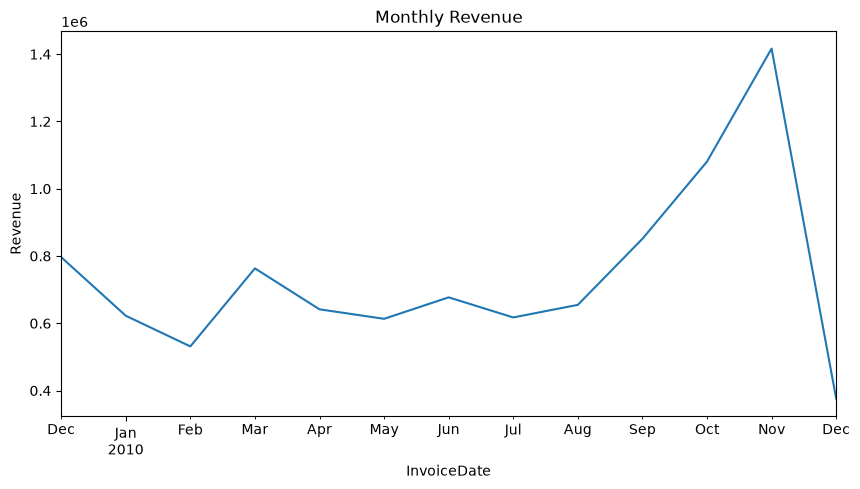

In [44]:
import matplotlib.pyplot as plt

df_clean['Revenue']= df_clean['Quantity']*df_clean['Price']
monthly_revenue=df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

monthly_revenue.plot(kind='line', figsize=(10,5), title='Monthly Revenue')
plt.ylabel('Revenue')
plt.show()

In [45]:
df_clean['InvoiceDate'].min(), df_clean['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

In [46]:
df_clean[df_clean['InvoiceDate'].dt.to_period('M') == '2010-12']['InvoiceDate'].dt.day.max()

np.int32(9)

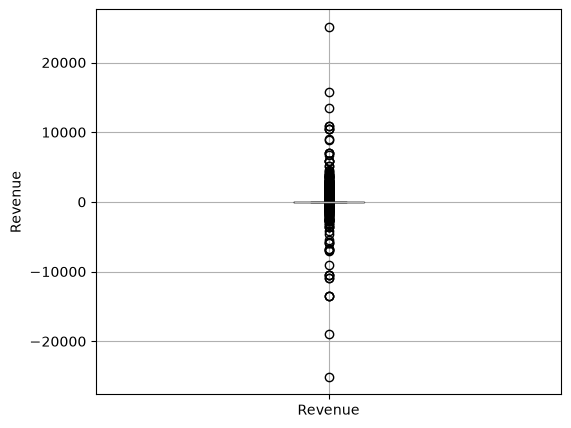

In [47]:
df_clean.boxplot(column='Revenue', figsize=(6,5))
plt.ylabel('Revenue')
plt.show()

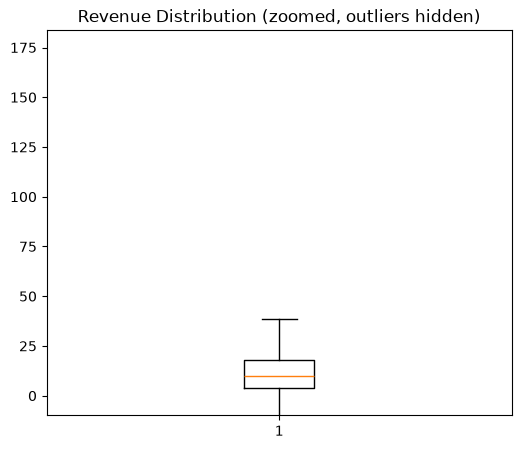

In [48]:
# Zoom into the 1st-99th percentile range to actually see the "box"
q_low = df_clean['Revenue'].quantile(0.01)
q_high = df_clean['Revenue'].quantile(0.99)

plt.figure(figsize=(6, 5))
plt.boxplot(df_clean['Revenue'], showfliers=False)
plt.ylim(q_low, q_high)
plt.title('Revenue Distribution (zoomed, outliers hidden)')
plt.show()

In [49]:
# Now actually look at the top 10 highest-revenue transactions
df_clean.sort_values('Revenue', ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
236752,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
423720,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40
507552,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
132227,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
132229,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
351587,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
365540,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,10468.80
335346,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80
73092,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
223238,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,8925.00


In [52]:
df_clean['StockCode'].value_counts().head(20)

StockCode
85123A    3468
22423     2201
85099B    2042
21212     1900
21232     1806
20725     1594
84879     1442
84991     1378
21754     1359
20914     1259
21931     1210
21080     1201
22139     1182
21977     1181
22383     1177
22138     1172
20727     1162
82494L    1155
21843     1143
21034     1139
Name: count, dtype: int64

In [55]:
non_product_codes = df_clean[~df_clean['StockCode'].str[0].str.isdigit()]['StockCode'].unique()
print(non_product_codes)
print(len(non_product_codes))

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
     'DCGS0072', 'gift_0001_80', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST',            'm',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
     'DCGS0041', 'gift_0001_70',     'DCGS0037',     'DCGSSBOY',
    'DCGSSGIRL',      'ADJUST2', 'gift_0001_40',       'SP1002',
     'DCGS0062',    'AMAZONFEE']
Length: 38, dtype: str
38


In [57]:
summary=df_clean[df_clean['StockCode'].isin(non_product_codes)].groupby('StockCode').agg(
    description=('Description','first'),
    count=('StockCode','size'),
    total_revenue=('Revenue','sum')
).sort_values('count', ascending=False)

print(summary.to_string())

                                      description  count  total_revenue
StockCode                                                              
POST                                      POSTAGE    862      46092.360
M                                          Manual    844     -14137.840
DOT                                DOTCOM POSTAGE    732     116401.990
C2                                       CARRIAGE    136       6400.000
D                                        Discount    100      -7788.320
ADJUST        Adjustment by john on 26/01/2010 16     67       6835.240
BANK CHARGES                         Bank Charges     65     -28386.990
S                                         SAMPLES     41      -3016.410
DCGS0058                         MISO PRETTY  GUM     30         34.820
gift_0001_30   Dotcomgiftshop Gift Voucher £30.00     17        434.560
gift_0001_20   Dotcomgiftshop Gift Voucher £20.00     17        304.010
PADS                   PADS TO MATCH ALL CUSHIONS     15        

In [58]:
df_clean[df_clean['StockCode'] == 'S'][['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,41.000000,41.000000,41.000000
mean,-0.951220,77.170976,-73.570976
std,0.312348,113.395776,115.822449
min,-1.000000,2.880000,-605.180000
25%,-1.000000,9.990000,-88.740000
50%,-1.000000,40.000000,-32.030000
75%,-1.000000,88.740000,-9.490000
max,1.000000,605.180000,73.800000
